## Упражнения по библиотеке Numpy

In [1]:
import numpy as np

**1.** Дан случайный массив, поменять знак у элементов, значения которых между 3 и 8

In [2]:
arr = np.random.randint(10, size=(1,5))
print(arr)

bool_idx = (arr > 3) & (arr < 8)
print(bool_idx)

arr[bool_idx] *= -1
print(arr)

[[2 3 9 8 2]]
[[False False False False False]]
[[2 3 9 8 2]]


**2.** Заменить максимальный элемент случайного массива на 0

In [3]:
arr = np.random.randint(10, size=(1,5))
print(arr)

max_el = np.max(arr)
print(max_el)

bool_idx = arr == max_el
arr[bool_idx] = 0
print(arr)

[[9 0 5 8 5]]
9
[[0 0 5 8 5]]


**3.** Построить прямое произведение массивов (все комбинации с каждым элементом). На вход подается двумерный массив

In [4]:
arr = np.array([[1, 2, 3], [4, 5, 6]])

grid = tuple()
count_elem = len(arr)

for i in range(count_elem):
    grid += (len(arr[i]) ,)

result = np.indices(grid, dtype=int)
result = result.reshape(count_elem, -1).T

for n, elem in enumerate(arr):
    result[:, n] = arr[n][result[:, n]]

print(result)

[[1 4]
 [1 5]
 [1 6]
 [2 4]
 [2 5]
 [2 6]
 [3 4]
 [3 5]
 [3 6]]


**4.** Даны 2 массива A (8x3) и B (2x2). Найти строки в A, которые содержат элементы из каждой строки в B, независимо от порядка элементов в B

In [5]:
A = np.random.randint(0,5,(5,3))
B = np.random.randint(0,5,(2,2))
print(A)
print()
print(B)

"""В NumPy добавлять новые оси можно с помощью специального объекта np.newaxis. """
C = (A[..., np.newaxis, np.newaxis] == B)
rows = (C.sum(axis=(1,2,3)) >= B.shape[1]).nonzero()[0]

print()
print(rows)

[[0 2 0]
 [0 2 4]
 [3 1 4]
 [2 3 2]
 [0 4 3]]

[[4 1]
 [0 2]]

[0 1 2 3 4]


**5.** Дана 10x3 матрица, найти строки из неравных значений (например строка [2,2,3] остается, строка [3,3,3] удаляется)

In [6]:
array = np.random.randint(5, size=(10,3))
print(array)
new_array = array.copy()

for ind, arr in enumerate(array):
    count = 0
# Подсчёт количества повторений первого элемента в списке
    for i in range(len(arr)):
        if (arr[i] == arr[0]):
            count += 1
    
    if count == len(arr):
        new_array = np.delete(new_array, ind, axis=0)

print()
print(new_array)

[[4 4 2]
 [1 1 3]
 [3 4 3]
 [0 3 3]
 [3 1 4]
 [1 3 2]
 [1 3 0]
 [1 2 4]
 [1 2 1]
 [1 2 3]]

[[4 4 2]
 [1 1 3]
 [3 4 3]
 [0 3 3]
 [3 1 4]
 [1 3 2]
 [1 3 0]
 [1 2 4]
 [1 2 1]
 [1 2 3]]


**6.** Дан двумерный массив. Удалить те строки, которые повторяются

In [7]:
array = np.array([[1, 2, 3], [4, 5, 6], [1, 2, 3], [0, 5, 9]])

unique_rows = np.unique(array, axis=0)
print(unique_rows)

[[0 5 9]
 [1 2 3]
 [4 5 6]]


______
______

Для каждой из следующих задач (1-5) нужно привести 2 реализации – одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная с использованием numpy (без использования питоновских циклов/map/list comprehension).


__Замечание 1.__ Можно считать, что все указанные объекты непустые (к примеру, в __задаче 1__ на диагонали матрицы есть ненулевые элементы).

__Замечание 2.__ Для большинства задач решение занимает не больше 1-2 строк.

___

* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ 3.

In [8]:
X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]])
diagonal_elements = np.diag(X)[np.diag(X)!=0]
prod = np.prod(diagonal_elements)
print(prod)

3


In [9]:
arr = [[1, 2, 3],
       [4, 0, 6],
       [7, 8, 9],
       [4, 4, 4]]

prod = 1

for i in range(len(arr)): 
    for j in range(len(arr[0])):
        if i == j:
            if arr[i][i] != 0:
                prod *= arr[i][i]

print(prod) 

9


* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ True.

In [10]:
"""Мультимножество — модификация понятия множества, 
допускающая включение одного и того же элемента в совокупность по нескольку раз."""
x = np.array([1, 2, 2, 4])
y = np.array([4, 2, 1, 2])

arr_equal = np.array_equal(np.sort(x), np.sort(y))
arr_equal

True

In [11]:
x = [1, 2, 2, 4]
y = [4, 2, 1, 2]

arr_equal = ((x.sort() == y.sort()) & (len(x) == len(y)))
arr_equal

True

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит ноль. 
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ 5.

In [12]:
x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0])
#индексы элементов, равных 0, кроме последнего
zero_ind = np.where(x[:-1] == 0)
# срез: начиная с индекса 1. В новом срезе учитываем элементы по найденными индексам, т.о. получаем следующие после нуля. 
max_el = np.max(x[1:][zero_ind])
max_el

np.int64(5)

In [13]:
x = [6, 2, 0, 3, 0, 0, 5, 7, 0]

new_list = []

for i in range(1, len(x)):
    if x[i - 1] == 0:
        new_list.append(x[i])

max_el = max(new_list, default=None)
max_el

5

* __Задача 4__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ (np.array([2, 3, 5]), np.array([3, 3, 1])).

In [14]:
x = np.array([2, 2, 2, 3, 3, 3, 5])

if len(x) == 0:  
    print((np.array([]), np.array([])))

diffs = np.diff(x)
# индексы, где diff не равен нулю
indices = np.where(diffs != 0)[0] + 1  
 
# concatenate() - объединение массивов
# Сохраняем индексы начала и конца изменений:
ind_starts = np.concatenate(([0], indices))  
ind_ends = np.concatenate((indices, [len(x)])) 

# длина изменений (количество повторяющихся элементов)
ind_lengths = ind_ends - ind_starts
# по одному элементу, где начинаются изменения
values = x[ind_starts]

result = (values, ind_lengths)
print(result)

(array([2, 3, 5]), array([3, 3, 1]))


In [15]:
"""
Функция groupby() модуля itertools создает итератор, который возвращает последовательные ключи и группы 
из итерируемой последовательности iterable.
"""
from itertools import groupby
 
x = [2, 2, 2, 3, 3, 3, 5]
uniq_elem = []
count_elem = []

for key, group in groupby(x):
    items = (key, len(list(group)))
    uniq_elem.append(items[0])
    count_elem.append(items[1])

result = (uniq_elem, count_elem)
print(result)

([2, 3, 5], [3, 3, 1])


* __Задача 5__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Сравните с функцией scipy.spatial.distance.cdist по скорости работы.

Евклидово расстояние - это расстояние (кратчайшая прямая) между двумя точками в пространстве. Евклидово расстояние рассчитывается с помощью теоремы Пифагора, учитывая декартовы координаты двух точек.

In [16]:
"""Свой пример для понимания"""
X = np.array((0, 0, 0))
Y = np.array((3, 3, 3))

square = np.square(X - Y)
sum_square = np.sum(square) #(0-3)^2 + (0-3)^2 + (0-3)^2
#np.sqrt() - функция квадратного корня
distance = np.sqrt(sum_square)
print(distance)

5.196152422706632


In [17]:
"""С помощью NumPy мы можем использовать функцию np.dot().
   Если мы вычислим точечное произведение разницы между обеими точками с той же разницей - мы получим число, 
   которое находится в зависимости от евклидова расстояния между этими двумя векторами. 
   Извлечение квадратного корня из этого числа дает нам расстояние, которое мы ищем.
   
   Функция Numpy outer() используется для вычисления внешних произведений двух векторов.
"""
def distNumpy(obj1, obj2):
   prod_outer = np.add.outer(np.sum(np.square(obj1), axis=1), np.sum(np.square(obj2), axis=1)) #напр, ((0)^2 + (0)^2 + (0)^2) + ((3)^2 + (3)^2 + (3)^2)
   #стандартное умножение матриц
   prod = np.dot(obj1, obj2.T)
   distances_np = np.sqrt(prod_outer - 2*prod)
   return distances_np

"""Функция cdist""" 
def distScipy(obj1, obj2):
   from scipy.spatial.distance import cdist
   distances_cdist = cdist(obj1, obj2)
   return distances_cdist

X = np.array([[0, 0, 0], [2, 0, 2]])
Y = np.array([[3, 3, 3], [4, 4, 4]])

print(distNumpy(X, Y))
print(distScipy(X, Y))


[[5.19615242 6.92820323]
 [3.31662479 4.89897949]]
[[5.19615242 6.92820323]
 [3.31662479 4.89897949]]


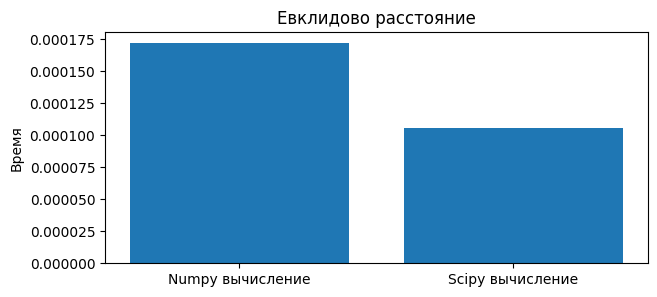

In [18]:
"""Сравнение по скорости работы"""
import time
import matplotlib.pyplot as plt

X = np.array([[0, 0, 0], [2, 0, 2]])
Y = np.array([[3, 3, 3], [4, 4, 4]])
  
start_time1 = time.time()
distNumpy(X, Y)
end_time1 = time.time()
time_numpy = end_time1 - start_time1

start_time2 = time.time()
distScipy(X, Y)
end_time2 = time.time()
time_scipy = end_time2 - start_time2

plt.figure(figsize=(7, 3))
plt.bar(['Numpy вычисление', 'Scipy вычисление'], [time_numpy, time_scipy])
plt.ylabel('Время')
plt.title('Евклидово расстояние')
plt.show()


_______
________

* #### __Задача 6__: CrunchieMunchies __*__

Вы работаете в отделе маркетинга пищевой компании MyCrunch, которая разрабатывает новый вид вкусных, полезных злаков под названием **CrunchieMunchies**.

Вы хотите продемонстрировать потребителям, насколько полезны ваши хлопья по сравнению с другими ведущими брендами, поэтому вы собрали данные о питании нескольких разных конкурентов.

Ваша задача - использовать вычисления Numpy для анализа этих данных и доказать, что ваши **СrunchieMunchies** - самый здоровый выбор для потребителей.


In [19]:
import numpy as np

1. Просмотрите файл cereal.csv. Этот файл содержит количества калорий для различных марок хлопьев. Загрузите данные из файла и сохраните их как calorie_stats.

In [20]:
calorie_stats = np.loadtxt(r"D:\Projects\de_courses\data\cereal.csv", delimiter=",")
calorie_stats

array([ 70., 120.,  70.,  50., 110., 110., 110., 130.,  90.,  90., 120.,
       110., 120., 110., 110., 110., 100., 110., 110., 110., 100., 110.,
       100., 100., 110., 110., 100., 120., 120., 110., 100., 110., 100.,
       110., 120., 120., 110., 110., 110., 140., 110., 100., 110., 100.,
       150., 150., 160., 100., 120., 140.,  90., 130., 120., 100.,  50.,
        50., 100., 100., 120., 100.,  90., 110., 110.,  80.,  90.,  90.,
       110., 110.,  90., 110., 140., 100., 110., 110., 100., 100., 110.])

2. В одной порции CrunchieMunchies содержится 60 калорий. Насколько выше среднее количество калорий у ваших конкурентов?

Сохраните ответ в переменной average_calories и распечатайте переменную в терминале

In [21]:
average_calories = np.mean(calorie_stats)
print(average_calories)

106.88311688311688


3. Корректно ли среднее количество калорий отражает распределение набора данных? Давайте отсортируем данные и посмотрим.

Отсортируйте данные и сохраните результат в переменной calorie_stats_sorted. Распечатайте отсортированную информацию

In [22]:
calorie_stats_sorted = np.sort(calorie_stats)
calorie_stats_sorted

array([ 50.,  50.,  50.,  70.,  70.,  80.,  90.,  90.,  90.,  90.,  90.,
        90.,  90., 100., 100., 100., 100., 100., 100., 100., 100., 100.,
       100., 100., 100., 100., 100., 100., 100., 100., 110., 110., 110.,
       110., 110., 110., 110., 110., 110., 110., 110., 110., 110., 110.,
       110., 110., 110., 110., 110., 110., 110., 110., 110., 110., 110.,
       110., 110., 110., 110., 120., 120., 120., 120., 120., 120., 120.,
       120., 120., 120., 130., 130., 140., 140., 140., 150., 150., 160.])

4. Похоже, что большинство значений выше среднего. Давайте посмотрим, является ли медиана наиболее корректным показателем набора данных.

Вычислите медиану набора данных и сохраните свой ответ в median_calories. Выведите медиану, чтобы вы могли видеть, как она сравнивается со средним значением.

In [23]:
median_calories = np.median(calorie_stats_sorted)
print(median_calories)

110.0


5. В то время как медиана показывает, что по крайней мере половина наших значений составляет более 100 калорий, было бы более впечатляюще показать, что значительная часть конкурентов имеет более высокое количество калорий, чем CrunchieMunchies.

Рассчитайте различные процентили и распечатайте их, пока не найдете наименьший процентиль, превышающий 60 калорий. Сохраните это значение в переменной nth_percentile.

In [40]:
# мы уже знаем, что 50% процентиль (медиана) превышает 60 калорий
        
for i in range(50):
    nth_percentile = np.percentile(calorie_stats_sorted, i)
    
    if nth_percentile <= 60:
        print(i, nth_percentile)
    else:
        nth_percentile = np.percentile(calorie_stats_sorted, i - 1)
        break

0 50.0
1 50.0
2 50.0
3 55.599999999999994


6. Хотя процентиль показывает нам, что у большинства конкурентов количество калорий намного выше, это неудобная концепция для использования в маркетинговых материалах.

Вместо этого давайте подсчитаем процент хлопьев, в которых содержится более 60 калорий на порцию. Сохраните свой ответ в переменной more_calories и распечатайте его

In [25]:
indices = np.where(calorie_stats_sorted > 60)
more_calories = np.size(indices)*100 / np.size(calorie_stats_sorted)
print(more_calories)

96.1038961038961


7. Это действительно высокий процент. Это будет очень полезно, когда мы будем продвигать CrunchieMunchies. Но один вопрос заключается в том, насколько велики различия в наборе данных? Можем ли мы сделать обобщение, что в большинстве злаков содержится около 100 калорий или разброс еще больше?

Рассчитайте величину отклонения, найдя стандартное отклонение, Сохраните свой ответ в calorie_std и распечатайте на терминале. Как мы можем включить эту ценность в наш анализ?

In [26]:
calorie_std = np.std(calorie_stats_sorted)
print(calorie_std)

19.35718533390827


8. Напишите короткий абзац, в котором кратко изложите свои выводы и то, как, по вашему мнению, эти данные могут быть использованы в интересах Mycrunch при маркетинге CrunchieMunchies.

Был произведен анализ количества калорий для различных марок хлопьев.
Как известно, в одной порции CrunchieMunchies содержится 60 калорий. 
Анализ данных показал, что 96% хлопьев других производителей содержат более 60 калорий на порцию. 


При этом, среднее количество калорий у конкурентов = 106. А стандартное отклонение = 19, что показывает разброс значений относительно среднего. Это значит, что в большинстве злаков содержится калорий больше среднего, т.е. больше 106-ти.

Анализ доказывает, что хлопья **СrunchieMunchies** - самый здоровый выбор для потребителей.